# CHECK ENVIRONMENT SELECT KERNEL

In [ ]:
import sys
print(sys.executable)

# STEP 1 (A) — LOAD AND PREPROCESS GNSS VTEC

---

## 🌍 Data Source

<div style="padding:10px; border-left:5px solid #2E86C1; background-color:#EAF2F8;">
<b>VTEC Data Acquired From:</b><br>
<a href="https://arplsrv.ictp.it" target="_blank">ICTP Calibrated GNSS TEC Service</a>
</div>

---


In [705]:
# ============================================================
# STEP 1 — Load all daily files from multiple year folders
# ============================================================

base_path = '/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/Data_Preprocessed/mbar/'

# Find all year folders (mbar_14, mbar_15, etc.)
year_folders = sorted([f for f in os.listdir(base_path) if f.startswith('mbar_')])

print(f"Year folders found: {year_folders}")

all_files = []

for year_folder in year_folders:
    folder_path = os.path.join(base_path, year_folder)
    # Extract year from folder name (e.g., 'mbar_14' -> '14')
    year = year_folder.split('_')[1]
    
    # Find all files matching pattern for this year
    files = glob.glob(os.path.join(folder_path, f'mbarF3_*.{year}A'))
    
    for f in files:
        if os.path.isfile(f):
            all_files.append(f)

all_files = sorted(all_files)

print(f"Total files found : {len(all_files)}")
print(f"First file        : {os.path.basename(all_files[0])}")
print(f"Last file         : {os.path.basename(all_files[-1])}")

# ============================================================
# STEP 2 — Single-day loader (modified to handle year)
# ============================================================

def load_day(fp):
    basename = os.path.basename(fp)
    day_num = int(basename.split('_')[1].split('.')[0])
    
    # Extract year from filename (e.g., 'mbarF3_001.14A' -> '14')
    year_str = basename.split('.')[-1].replace('A', '')
    year = int(2000 + int(year_str))  # 14 -> 2014, 15 -> 2015
    
    try:
        df = pd.read_csv(
            fp,
            sep=r'\s+',
            skiprows=5,
            names=['Time', 'PRN', 'PP', 'Az', 'El', 'Lon', 'Lat', 'TEC']
        )
    except Exception as e:
        print(f"ERROR loading {basename}: {e}")
        return None

    df = df[df['PRN'] == 'Z00'].copy()

    if len(df) == 0:
        print(f"WARNING: No Z00 data in {basename}")
        return None

    df = df.reset_index(drop=True)

    # ============================================================
    # FEATURE ENGINEERING
    # ============================================================

    df['VTEC'] = df['TEC']
    df['Day'] = day_num
    df['Time_Min'] = df['Time'] / 60.0
    df['Time_h'] = df['Time'] / 3600.0
    df['ROT'] = df['VTEC'].diff() / df['Time_Min'].diff()
    

    # ============================================================
    # FULL DATETIME CREATION (dynamic year)
    # ============================================================

    df['datetime'] = (
        pd.to_datetime(f'{year}-01-01') +
        pd.to_timedelta(df['Day'] - 1, unit='D') +
        pd.to_timedelta(df['Time'], unit='s')
    )

    # ============================================================
    # CYCLICAL TIME FEATURES
    # ============================================================

    df['sin_time'] = np.sin(2 * np.pi * df['Time_h'] / 24)
    df['cos_time'] = np.cos(2 * np.pi * df['Time_h'] / 24)

    return df

# ============================================================
# STEP 3 — Load all files
# ============================================================

all_days = []
failed = []

for fp in all_files:
    day_df = load_day(fp)
    if day_df is not None:
        all_days.append(day_df)
    else:
        failed.append(os.path.basename(fp))

print(f"Successfully loaded : {len(all_days)} days")
print(f"Failed/empty        : {len(failed)} files")

# ============================================================
# STEP 4 — Create annual dataframe (now multi-year)
# ============================================================

df_all_years = pd.concat(all_days, ignore_index=True)

df_all_years = df_all_years.sort_values('datetime').reset_index(drop=True)

print(f"\nTotal date range: {df_all_years['datetime'].min()} to {df_all_years['datetime'].max()}")
print(f"Years covered: {df_all_years['datetime'].dt.year.unique()}")


df_year = df_all_years

df_year


Year folders found: ['mbar_13', 'mbar_14', 'mbar_15', 'mbar_16', 'mbar_17', 'mbar_18', 'mbar_19', 'mbar_20']
Total files found : 2078
First file        : mbarF3_001.13A
Last file         : mbarF3_277.20A
Successfully loaded : 2069 days
Failed/empty        : 9 files

Total date range: 2013-01-01 00:00:00 to 2020-10-03 23:59:30
Years covered: [2013 2014 2015 2016 2017 2018 2019 2020]


,Time,PRN,PP,Az,El,Lon,Lat,TEC,VTEC,Day,Time_Min,Time_h,ROT,datetime,sin_time,cos_time
0,0,Z00,0.0,90.0,30.738,-0.601,43.10,43.10,43.10,1,0.0,0.000000,NaN,2013-01-01 00:00:00,0.000000,1.000000
1,30,Z00,0.0,90.0,30.738,-0.601,43.09,43.09,43.09,1,0.5,0.008333,-0.02,2013-01-01 00:00:30,0.002182,0.999998
2,60,Z00,0.0,90.0,30.738,-0.601,43.09,43.09,43.09,1,1.0,0.016667,0.00,2013-01-01 00:01:00,0.004363,0.999990
3,90,Z00,0.0,90.0,30.738,-0.601,43.09,43.09,43.09,1,1.5,0.025000,0.00,2013-01-01 00:01:30,0.006545,0.999979
4,120,Z00,0.0,90.0,30.738,-0.601,43.09,43.09,43.09,1,2.0,0.033333,0.00,2013-01-01 00:02:00,0.008727,0.999962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5036136,86250,Z00,0.0,90.0,30.738,-0.601,-6.06,-6.06,-6.06,277,1437.5,23.958333,0.02,2020-10-03 23:57:30,-0.010908,0.999941
5036137,86280,Z00,0.0,90.0,30.738,-0.601,-6.05,-6.05,-6.05,277,1438.0,23.966667,0.02,2020-10-03 23:58:00,-0.008727,0.999962
5036138,86310,Z00,0.0,90.0,30.738,-0.601,-6.04,-6.04,-6.04,277,1438.5,23.975000,0.02,2020-10-03 23:58:30,-0.006545,0.999979
5036139,86340,Z00,0.0,90.0,30.738,-0.601,-6.04,-6.04,-6.04,277,1439.0,23.983333,0.00,2020-10-03 23:59:00,-0.004363,0.999990


# STEP 1 (B) — LOAD AND PREPROCESS Kp, Ap, Dst, F10.7

---

## 🌍 Data Source

<div style="padding:10px; border-left:5px solid #2E86C1; background-color:#EAF2F8;">
<b>VTEC Data Acquired From:</b><br>
<a href="https://www.ncei.noaa.gov/products/geomagnetic-indices" target="_blank">National Centers for
Environmental Information
(NATIONAL OCEANIC AND ATMOSPHERIC ADMINISTRATION)</a>
</div>

---


In [706]:
# ============================================================
# PART 1 — LOAD NOAA/GFZ GEOMAGNETIC DATA
# ============================================================

import pandas as pd
import numpy as np

# Path to NOAA/GFZ fixed-width Kp/AP dataset
kp_file = '/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/Data_Preprocessed/noaa_data/kp_ap_13_18.txt'


# ============================================================
# STEP 1 — DEFINE FIXED WIDTH STRUCTURE
# ============================================================

colspecs = [
    (0,2),(2,4),(4,6),                         # YY MM DD
    (6,10),(10,12),                            # Bartels rotation info

    (12,14),(14,16),(16,18),(18,20),           # Kp1–Kp4
    (20,22),(22,24),(24,26),(26,28),           # Kp5–Kp8

    (28,31),                                   # Kp sum

    (31,34),(34,37),(37,40),(40,43),           # ap1–ap4
    (43,46),(46,49),(49,52),(52,55),           # ap5–ap8

    (55,58),(58,61),(61,62),                   # Ap, Cp, C9
    (62,65),(65,70),(70,71)                    # Sunspot, F10.7, qualifier
]

names = [
    'YY','MM','DD',
    'Bartels_Rotation','Bartels_Day',

    'Kp1','Kp2','Kp3','Kp4',
    'Kp5','Kp6','Kp7','Kp8',

    'Kp_sum',

    'ap1','ap2','ap3','ap4',
    'ap5','ap6','ap7','ap8',

    'Ap','Cp','C9',
    'Sunspot_Number','F10_7','Flux_Qualifier'
]


# ============================================================
# STEP 2 — LOAD RAW FILE
# ============================================================

kp_raw = pd.read_fwf(
    kp_file,
    colspecs=colspecs,
    names=names
)
# Reads fixed-width NOAA geomagnetic dataset (keeps NaN as-is)


# ============================================================
# STEP 3 — BUILD DATE COLUMN
# ============================================================

kp_raw['Year'] = 2000 + kp_raw['YY']
# Convert YY → full year (2014 etc.)

kp_raw['Date'] = pd.to_datetime({
    'year': kp_raw['Year'],
    'month': kp_raw['MM'],
    'day': kp_raw['DD']
})
# Build proper daily timestamp


# ============================================================
# STEP 4 — EXPAND TO 3-HOUR RESOLUTION (NOAA STANDARD)
# ============================================================

kp_rows = []

for _, row in kp_raw.iterrows():

    base_date = row['Date']
    # Daily reference timestamp

    kp_values = [
        row['Kp1'], row['Kp2'], row['Kp3'], row['Kp4'],
        row['Kp5'], row['Kp6'], row['Kp7'], row['Kp8']
    ]
    # 8 Kp values (3-hour resolution)

    ap_values = [
        row['ap1'], row['ap2'], row['ap3'], row['ap4'],
        row['ap5'], row['ap6'], row['ap7'], row['ap8']
    ]
    # 8 ap values (3-hour resolution)

    for i in range(8):

        kp_rows.append({

            'start_time': base_date + pd.Timedelta(hours=i*3),
            # Start of 3-hour window (used for merge_asof)

            'end_time': base_date + pd.Timedelta(hours=(i+1)*3),
            # End of 3-hour window (useful for validation)

            'Kp': kp_values[i] / 10.0,
            # Convert NOAA Kp (×10 scale) → real value

            'ap': ap_values[i],
            # 3-hour ap index

            'Daily_Ap': row['Ap'],
            # Daily Ap index (full-day geomagnetic activity)

            'Cp': row['Cp'],
            # Planetary daily character index

            'C9': row['C9'],
            # Additional geomagnetic index

            'F10_7': row['F10_7'],
            # Solar flux index

            'Sunspot_Number': row['Sunspot_Number'],
            # Solar activity indicator

            'Flux_Qualifier': row['Flux_Qualifier']
            # Data quality flag (important for filtering later)
        })


# Convert list to DataFrame
kp_df = pd.DataFrame(kp_rows)
# Final structured geomagnetic dataset (3-hour resolution)


# ============================================================
# STEP 5 — FINAL SORT (IMPORTANT FOR MERGE_ASOF)
# ============================================================

kp_df = kp_df.sort_values('start_time').reset_index(drop=True)
# Ensure chronological order for forward-fill merging


# ============================================================
# STEP 6 — VERIFY STRUCTURE
# ============================================================

print(kp_df)
# Show first rows

print("\nKp time range:")
print(kp_df['start_time'].min(), "→", kp_df['end_time'].max())
# Confirm full temporal coverage

               start_time            end_time   Kp  ap  Daily_Ap   Cp  C9  \
0     2013-01-01 00:00:00 2013-01-01 03:00:00  0.7   3         1  0.0   0   
1     2013-01-01 03:00:00 2013-01-01 06:00:00  0.3   2         1  0.0   0   
2     2013-01-01 06:00:00 2013-01-01 09:00:00  0.3   2         1  0.0   0   
3     2013-01-01 09:00:00 2013-01-01 12:00:00  0.0   0         1  0.0   0   
4     2013-01-01 12:00:00 2013-01-01 15:00:00  0.3   2         1  0.0   0   
...                   ...                 ...  ...  ..       ...  ...  ..   
15563 2018-04-30 09:00:00 2018-04-30 12:00:00  0.7   3         5  0.2   1   
15564 2018-04-30 12:00:00 2018-04-30 15:00:00  2.0   7         5  0.2   1   
15565 2018-04-30 15:00:00 2018-04-30 18:00:00  1.7   6         5  0.2   1   
15566 2018-04-30 18:00:00 2018-04-30 21:00:00  1.3   5         5  0.2   1   
15567 2018-04-30 21:00:00 2018-05-01 00:00:00  0.0   0         5  0.2   1   

       F10_7 Sunspot_Number  Flux_Qualifier  
0      113.9             65  

## STEP 2 (B) — Merge Kp, Ap, Dst, F10.7 with df_year


In [707]:
# ============================================================
# STEP 0 — SORT BOTH DATASETS (REQUIRED FOR merge_asof)
# ============================================================

df_year = df_year.sort_values('datetime').reset_index(drop=True)
# Ensure ROTI dataset is time-ordered

kp_df = kp_df.sort_values('start_time').reset_index(drop=True)
# Ensure Kp dataset is time-ordered

# Drop unnecessary columns from df_year before merging (optional but cleaner)
df_year = df_year.drop(columns=[
    'start_time',
    'end_time',
    'Kp',
    'ap',
    'Daily_Ap',
    'Cp',
    'C9',
    'F10_7',
    'Sunspot_Number',
    'Flux_Qualifier'
], errors='ignore')

# ============================================================
# STEP 1 — FORWARD FILL MERGE (NO LOOP METHOD)
# ============================================================

df_year = pd.merge_asof(
    df_year,
    kp_df,
    left_on='datetime',
    right_on='start_time',
    direction='backward'
)
# Assigns each ROTI timestamp the most recent previous Kp/ap values


# ============================================================
# STEP 2 — CLEAN UNNECESSARY COLUMN (OPTIONAL)
# ============================================================

df_year = df_year.drop(columns=['end_time'])
# Remove interval end_time (not needed for ML)


# ============================================================
# STEP 3 — KEEP MISSING VALUES (IMPORTANT)
# ============================================================

# DO NOT drop NaN values
# We keep missing days for future imputation / modeling


# ============================================================
# STEP 4 — FINAL CHECK
# ============================================================

print(df_year)
# Show merged dataset sample


print("\nFinal dataset shape:")
print(df_year.shape)
# Show final size

          Time  PRN   PP    Az      El    Lon    Lat    TEC   VTEC  Day  \
0            0  Z00  0.0  90.0  30.738 -0.601  43.10  43.10  43.10    1   
1           30  Z00  0.0  90.0  30.738 -0.601  43.09  43.09  43.09    1   
2           60  Z00  0.0  90.0  30.738 -0.601  43.09  43.09  43.09    1   
3           90  Z00  0.0  90.0  30.738 -0.601  43.09  43.09  43.09    1   
4          120  Z00  0.0  90.0  30.738 -0.601  43.09  43.09  43.09    1   
...        ...  ...  ...   ...     ...    ...    ...    ...    ...  ...   
5036136  86250  Z00  0.0  90.0  30.738 -0.601  -6.06  -6.06  -6.06  277   
5036137  86280  Z00  0.0  90.0  30.738 -0.601  -6.05  -6.05  -6.05  277   
5036138  86310  Z00  0.0  90.0  30.738 -0.601  -6.04  -6.04  -6.04  277   
5036139  86340  Z00  0.0  90.0  30.738 -0.601  -6.04  -6.04  -6.04  277   
5036140  86370  Z00  0.0  90.0  30.738 -0.601  -6.03  -6.03  -6.03  277   

         Time_Min     Time_h   ROT            datetime  sin_time  cos_time  \
0             0.0   0

In [708]:
# Clean up dataset by dropping unnecessary columns for modeling

df_year = df_year.drop(columns=['Flux_Qualifier','start_time'
    
], errors='ignore')

print("\nColumn list:")
# Print column title

print(df_year.columns.tolist())
# Print dataframe columns

df_year

# df_year.iloc[2860:2881]
# Print specified columns


Column list:
['Time', 'PRN', 'PP', 'Az', 'El', 'Lon', 'Lat', 'TEC', 'VTEC', 'Day', 'Time_Min', 'Time_h', 'ROT', 'datetime', 'sin_time', 'cos_time', 'Kp', 'ap', 'Daily_Ap', 'Cp', 'C9', 'F10_7', 'Sunspot_Number']


,Time,PRN,PP,Az,El,Lon,Lat,TEC,VTEC,Day,Time_Min,Time_h,ROT,datetime,sin_time,cos_time,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number
0,0,Z00,0.0,90.0,30.738,-0.601,43.10,43.10,43.10,1,0.0,0.000000,NaN,2013-01-01 00:00:00,0.000000,1.000000,0.7,3,1,0.0,0,113.9,65
1,30,Z00,0.0,90.0,30.738,-0.601,43.09,43.09,43.09,1,0.5,0.008333,-0.02,2013-01-01 00:00:30,0.002182,0.999998,0.7,3,1,0.0,0,113.9,65
2,60,Z00,0.0,90.0,30.738,-0.601,43.09,43.09,43.09,1,1.0,0.016667,0.00,2013-01-01 00:01:00,0.004363,0.999990,0.7,3,1,0.0,0,113.9,65
3,90,Z00,0.0,90.0,30.738,-0.601,43.09,43.09,43.09,1,1.5,0.025000,0.00,2013-01-01 00:01:30,0.006545,0.999979,0.7,3,1,0.0,0,113.9,65
4,120,Z00,0.0,90.0,30.738,-0.601,43.09,43.09,43.09,1,2.0,0.033333,0.00,2013-01-01 00:02:00,0.008727,0.999962,0.7,3,1,0.0,0,113.9,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5036136,86250,Z00,0.0,90.0,30.738,-0.601,-6.06,-6.06,-6.06,277,1437.5,23.958333,0.02,2020-10-03 23:57:30,-0.010908,0.999941,0.0,0,5,0.2,1,76.9,---
5036137,86280,Z00,0.0,90.0,30.738,-0.601,-6.05,-6.05,-6.05,277,1438.0,23.966667,0.02,2020-10-03 23:58:00,-0.008727,0.999962,0.0,0,5,0.2,1,76.9,---
5036138,86310,Z00,0.0,90.0,30.738,-0.601,-6.04,-6.04,-6.04,277,1438.5,23.975000,0.02,2020-10-03 23:58:30,-0.006545,0.999979,0.0,0,5,0.2,1,76.9,---
5036139,86340,Z00,0.0,90.0,30.738,-0.601,-6.04,-6.04,-6.04,277,1439.0,23.983333,0.00,2020-10-03 23:59:00,-0.004363,0.999990,0.0,0,5,0.2,1,76.9,---


In [709]:
# df_year.iloc[2870:2891]
df_year.iloc[3520:3540]
# Print specified columns

,Time,PRN,PP,Az,El,Lon,Lat,TEC,VTEC,Day,Time_Min,Time_h,ROT,datetime,sin_time,cos_time,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number
3520,86190,Z00,0.0,90.0,30.738,-0.601,16.10,16.10,16.10,2,1436.5,23.941667,-0.100000,2013-01-02 23:56:30,-0.015271,0.999883,0.7,3,4,0.1,0,115.0,62
3521,86220,Z00,0.0,90.0,30.738,-0.601,16.04,16.04,16.04,2,1437.0,23.950000,-0.120000,2013-01-02 23:57:00,-0.013090,0.999914,0.7,3,4,0.1,0,115.0,62
3522,86250,Z00,0.0,90.0,30.738,-0.601,15.99,15.99,15.99,2,1437.5,23.958333,-0.100000,2013-01-02 23:57:30,-0.010908,0.999941,0.7,3,4,0.1,0,115.0,62
3523,86280,Z00,0.0,90.0,30.738,-0.601,15.93,15.93,15.93,2,1438.0,23.966667,-0.120000,2013-01-02 23:58:00,-0.008727,0.999962,0.7,3,4,0.1,0,115.0,62
3524,86310,Z00,0.0,90.0,30.738,-0.601,15.88,15.88,15.88,2,1438.5,23.975000,-0.100000,2013-01-02 23:58:30,-0.006545,0.999979,0.7,3,4,0.1,0,115.0,62
3525,86340,Z00,0.0,90.0,30.738,-0.601,15.83,15.83,15.83,2,1439.0,23.983333,-0.100000,2013-01-02 23:59:00,-0.004363,0.999990,0.7,3,4,0.1,0,115.0,62
3526,86370,Z00,0.0,90.0,30.738,-0.601,15.77,15.77,15.77,2,1439.5,23.991667,-0.120000,2013-01-02 23:59:30,-0.002182,0.999998,0.7,3,4,0.1,0,115.0,62
3527,0,Z00,0.0,90.0,30.738,-0.601,19.61,19.61,19.61,3,0.0,0.000000,NaN,2013-01-03 00:00:00,0.000000,1.000000,1.7,6,2,0.0,0,124.6,85
3528,30,Z00,0.0,90.0,30.738,-0.601,19.59,19.59,19.59,3,0.5,0.008333,-0.040000,2013-01-03 00:00:30,0.002182,0.999998,1.7,6,2,0.0,0,124.6,85
3529,60,Z00,0.0,90.0,30.738,-0.601,19.57,19.57,19.57,3,1.0,0.016667,-0.040000,2013-01-03 00:01:00,0.004363,0.999990,1.7,6,2,0.0,0,124.6,85


# STEP 1 (C) — LOAD AND PREPROCESS STORM INDICATORS
### Field magnitude average-nT(F8.2), BZ-nT(GSM)(F8.2), Speed-km/s(F8.1), Proton Density-n/cc(F7.2), Electric field-mV/m(F7.2), AE-index-nT(I6), SYM/H-nT(I6) 

---

## 🌍 Data Source

<div style="padding:10px; border-left:5px solid #2E86C1; background-color:#EAF2F8;">
<b>VTEC Data Acquired From:</b><br>
<a href="https://omniweb.gsfc.nasa.gov/form/omni_min.html?utm_source=chatgpt.com" target="_blank">NASA</a>
</div>

---


In [710]:
# ============================================================
# PART 2 — LOAD NASA OMNI SOLAR WIND / GEOMAGNETIC DATA
# ============================================================

# Path to OMNI fixed-width dataset
omni_file = '/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/Data_Preprocessed/omni_data/omni_13_18_data.txt'


# ============================================================
# STEP 1 — DEFINE COLUMN WIDTHS
# ============================================================

colspecs = [
    (0,4),     # Year
    (4,8),     # Day of year
    (8,11),    # Hour
    (11,14),   # Minute
    (14,22),   # Magnetic field magnitude
    (22,30),   # Bz GSM
    (30,38),   # Solar wind speed
    (38,45),   # Proton density
    (45,52),   # Electric field
    (52,58),   # AE index
    (58,64)    # SYM/H
]

names = [
    'Year',
    'DOY',
    'Hour',
    'Minute',
    'Bt',
    'Bz_GSM',
    'Solar_Wind_Speed',
    'Proton_Density',
    'Electric_Field',
    'AE_Index',
    'SYM_H'
]


# ============================================================
# STEP 2 — LOAD RAW FILE
# ============================================================

nasa_df = pd.read_fwf(
    omni_file,
    colspecs=colspecs,
    names=names
)
# Reads OMNI fixed-width dataset


# ============================================================
# STEP 3a — BUILD DATETIME COLUMN
# ============================================================

nasa_df['datetime'] = (
    pd.to_datetime(nasa_df['Year'], format='%Y') +
    pd.to_timedelta(nasa_df['DOY'] - 1, unit='D') +
    pd.to_timedelta(nasa_df['Hour'], unit='h') +
    pd.to_timedelta(nasa_df['Minute'], unit='m')
)
# Convert Year + DOY + Hour + Minute into timestamp

# ============================================================
# STEP 3b — REPLACE OMNI MISSING VALUE FLAGS
# ============================================================

nasa_df = nasa_df.replace({

    9999.99: np.nan,
    # Missing magnetic field values

    99999.9: np.nan,
    # Missing solar wind speed

    999.99: np.nan,
    # Missing proton density / electric field

    999999: np.nan,
    # Missing AE index

    99999: np.nan
    # Missing SYM/H
})

# ============================================================
# STEP 4 — SORT DATASET
# ============================================================

nasa_df = nasa_df.sort_values('datetime').reset_index(drop=True)
# Ensure chronological order

# Clean up dataset by dropping unnecessary columns for modeling

nasa_df = nasa_df.drop(columns=[
    'Year',
    'DOY',
    'Hour',
    'Minute'
], errors='ignore')

# ============================================================
# STEP 5 — VERIFY STRUCTURE
# ============================================================

print(nasa_df)
# Show first rows


print("\nOMNI time range:")
print(nasa_df['datetime'].min(), "→", nasa_df['datetime'].max())
# Confirm temporal coverage

           Bt  Bz_GSM  Solar_Wind_Speed  Proton_Density  Electric_Field  \
0        2.45   -0.18             358.8            1.94             NaN   
1        2.45   -0.19             358.8            1.94            0.07   
2        2.45   -0.22             358.8            1.94            0.08   
3        2.43   -0.23             359.3            1.94            0.08   
4        2.43   -0.34             358.8            1.95            0.12   
...       ...     ...               ...             ...             ...   
3155035  4.88    3.19             452.7            4.49           -1.44   
3155036  4.70    3.44               NaN             NaN             NaN   
3155037  4.94    2.93               NaN             NaN             NaN   
3155038  4.89    3.10               NaN             NaN             NaN   
3155039  4.96    3.00               NaN             NaN             NaN   

         AE_Index  SYM_H            datetime  
0               9      1 2013-01-01 00:00:00  
1    

## STEP 2 (C) — Merge STORM INDICATORS with df_year



In [711]:
# ============================================================
# PART 3 — MERGE NASA OMNI DATA WITH df_year
# ============================================================

# ============================================================
# STEP 0 — SORT BOTH DATASETS
# ============================================================

df_year = df_year.sort_values(

    'datetime'

).reset_index(drop=True)
# Ensure GNSS dataset is chronologically ordered


nasa_df = nasa_df.sort_values(

    'datetime'

).reset_index(drop=True)
# Ensure OMNI dataset is chronologically ordered


# ============================================================
# STEP 1 — REMOVE OLD OMNI COLUMNS (SAFE RE-RUN)
# ============================================================

df_year = df_year.drop(columns=[

    'Bt',
    'Bz_GSM',
    'Solar_Wind_Speed',
    'Proton_Density',
    'Electric_Field',
    'AE_Index',
    'SYM_H'

], errors='ignore')
# Prevent duplicate columns if notebook cell is re-run


# ============================================================
# STEP 2 — MERGE USING TIME-ALIGNED FORWARD FILL
# ============================================================

df_year = pd.merge_asof(

    df_year,

    nasa_df[[
        'datetime',
        'Bt',
        'Bz_GSM',
        'Solar_Wind_Speed',
        'Proton_Density',
        'Electric_Field',
        'AE_Index',
        'SYM_H'
    ]],
    # Keep only required OMNI features

    on='datetime',
    # Match using timestamp

    direction='backward'
    # Assign most recent previous OMNI observation
)
# Scientifically correct for time-series causal alignment


# ============================================================
# STEP 3 — FINAL VALIDATION
# ============================================================

print(df_year.head)
# Show merged sample


print("\nMerged dataset shape:")
# Print dataset size title

print(df_year.shape)
# Show final dataframe dimensions


print("\nMerged time range:")
# Print time range title

print(
    df_year['datetime'].min(),
    "→",
    df_year['datetime'].max()
)
# Verify temporal coverage


print("\nMissing values after merge:")
# Print NaN summary title

print(
    df_year[[
        'Bt',
        'Bz_GSM',
        'Solar_Wind_Speed',
        'Proton_Density',
        'Electric_Field',
        'AE_Index',
        'SYM_H'
    ]].isna().sum()
)
# Check missing OMNI parameters

# ============================================================
# STEP 4 — FINAL CHECK
# ============================================================

print(df_year)
# Show merged dataset sample


print("\nFinal dataset shape:")
print(df_year.shape)
# Show final size

<bound method NDFrame.head of           Time  PRN   PP    Az      El    Lon    Lat    TEC   VTEC  Day  \
0            0  Z00  0.0  90.0  30.738 -0.601  43.10  43.10  43.10    1   
1           30  Z00  0.0  90.0  30.738 -0.601  43.09  43.09  43.09    1   
2           60  Z00  0.0  90.0  30.738 -0.601  43.09  43.09  43.09    1   
3           90  Z00  0.0  90.0  30.738 -0.601  43.09  43.09  43.09    1   
4          120  Z00  0.0  90.0  30.738 -0.601  43.09  43.09  43.09    1   
...        ...  ...  ...   ...     ...    ...    ...    ...    ...  ...   
5036136  86250  Z00  0.0  90.0  30.738 -0.601  -6.06  -6.06  -6.06  277   
5036137  86280  Z00  0.0  90.0  30.738 -0.601  -6.05  -6.05  -6.05  277   
5036138  86310  Z00  0.0  90.0  30.738 -0.601  -6.04  -6.04  -6.04  277   
5036139  86340  Z00  0.0  90.0  30.738 -0.601  -6.04  -6.04  -6.04  277   
5036140  86370  Z00  0.0  90.0  30.738 -0.601  -6.03  -6.03  -6.03  277   

         Time_Min     Time_h   ROT            datetime  sin_time  cos

In [712]:
print(df_year.columns.tolist())
# Print dataframe columns

df_year.iloc[2870:2891]


['Time', 'PRN', 'PP', 'Az', 'El', 'Lon', 'Lat', 'TEC', 'VTEC', 'Day', 'Time_Min', 'Time_h', 'ROT', 'datetime', 'sin_time', 'cos_time', 'Kp', 'ap', 'Daily_Ap', 'Cp', 'C9', 'F10_7', 'Sunspot_Number', 'Bt', 'Bz_GSM', 'Solar_Wind_Speed', 'Proton_Density', 'Electric_Field', 'AE_Index', 'SYM_H']


,Time,PRN,PP,Az,El,Lon,Lat,TEC,VTEC,Day,Time_Min,Time_h,ROT,datetime,sin_time,cos_time,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number,Bt,Bz_GSM,Solar_Wind_Speed,Proton_Density,Electric_Field,AE_Index,SYM_H
2870,65310,Z00,0.0,90.0,30.738,-0.601,29.11,29.11,29.11,2,1088.5,18.141667,-0.18,2013-01-02 18:08:30,-0.999312,0.037080,1.0,4,4,0.1,0,115.0,62,4.84,0.10,304.0,6.98,-0.03,45,-5
2871,65340,Z00,0.0,90.0,30.738,-0.601,29.03,29.03,29.03,2,1089.0,18.150000,-0.16,2013-01-02 18:09:00,-0.999229,0.039260,1.0,4,4,0.1,0,115.0,62,4.63,-0.51,307.4,7.09,0.16,43,-5
2872,65370,Z00,0.0,90.0,30.738,-0.601,28.94,28.94,28.94,2,1089.5,18.158333,-0.18,2013-01-02 18:09:30,-0.999141,0.041440,1.0,4,4,0.1,0,115.0,62,4.63,-0.51,307.4,7.09,0.16,43,-5
2873,65400,Z00,0.0,90.0,30.738,-0.601,28.85,28.85,28.85,2,1090.0,18.166667,-0.18,2013-01-02 18:10:00,-0.999048,0.043619,1.0,4,4,0.1,0,115.0,62,4.62,-1.62,307.4,7.09,0.50,39,-5
2874,65430,Z00,0.0,90.0,30.738,-0.601,28.76,28.76,28.76,2,1090.5,18.175000,-0.18,2013-01-02 18:10:30,-0.998951,0.045799,1.0,4,4,0.1,0,115.0,62,4.62,-1.62,307.4,7.09,0.50,39,-5
2875,65460,Z00,0.0,90.0,30.738,-0.601,28.68,28.68,28.68,2,1091.0,18.183333,-0.16,2013-01-02 18:11:00,-0.998848,0.047978,1.0,4,4,0.1,0,115.0,62,4.47,-2.24,304.0,6.83,0.68,32,-5
2876,65490,Z00,0.0,90.0,30.738,-0.601,28.59,28.59,28.59,2,1091.5,18.191667,-0.18,2013-01-02 18:11:30,-0.998741,0.050157,1.0,4,4,0.1,0,115.0,62,4.47,-2.24,304.0,6.83,0.68,32,-5
2877,65520,Z00,0.0,90.0,30.738,-0.601,28.50,28.50,28.50,2,1092.0,18.200000,-0.18,2013-01-02 18:12:00,-0.998630,0.052336,1.0,4,4,0.1,0,115.0,62,4.15,-2.54,302.9,7.38,0.77,25,-5
2878,65550,Z00,0.0,90.0,30.738,-0.601,28.41,28.41,28.41,2,1092.5,18.208333,-0.18,2013-01-02 18:12:30,-0.998513,0.054515,1.0,4,4,0.1,0,115.0,62,4.15,-2.54,302.9,7.38,0.77,25,-5
2879,65580,Z00,0.0,90.0,30.738,-0.601,28.33,28.33,28.33,2,1093.0,18.216667,-0.16,2013-01-02 18:13:00,-0.998392,0.056693,1.0,4,4,0.1,0,115.0,62,3.99,-3.11,301.2,8.20,0.94,25,-5


# Data Preprocessing

# 2.1 Quality Control
Apply 30° elevation mask (remove satellites below this angle).  
Remove rows with missing TEC/ROTI values.  
Remove outliers beyond physical ROTI limits (>1.0 TECU/min).  
Document number of rows removed.  

# 2.2 TEC Computation
Extract carrier phase measurements from L1 and L2 frequencies.  
Compute Slant TEC along each satellite-receiver path.  
Assume ionospheric pierce point altitude of 350 km.  

In [ ]:
# df_year = df_year.dropna(subset=['VTEC']).reset_index(drop=True)

# 2.3 ROT Computation
For each satellite-receiver pair, compute:  
ROT(i) = (TEC_k - TEC_{k-1}) / (t_k - t_{k-1})  
Where i = visible satellite, k = GPS epoch.  

# 2.4 ROTI Computation
Use 5-minute sliding window (10 samples at 30s sampling).  
Compute as standard deviation of ROT.  
Verify ROTI is your target variable.  

In [713]:
df_year['ROTI_5min'] = df_year['ROT'].rolling(window=10, min_periods=1).std() # 5-minute rolling standard deviation of ROT


# df_year['vtec_gradient'] = df_year['VTEC'].diff(periods=10) / 5.0

# df_year['rot_abs'] = df_year['ROT'].abs()

# df_year['rot_std_local'] = df_year['ROT'].rolling(window=10, min_periods=1).std()

# df_year['rot_accel'] = df_year['ROT'].diff()

In [714]:
# Clean up dataset by dropping unnecessary columns for modeling

df_year = df_year.drop(columns=['Time', 'PRN', 'PP', 'Az', 'El', 'Lon', 'Lat', 'TEC', 'Day', 'Time_Min', 'Time_h']
, errors='ignore')
df_year = df_year[df_year['datetime'].dt.year <= 2017].copy()
print("\nColumn list:")
# Print column title

print(df_year.columns.tolist())
# Print dataframe columns

df_year


Column list:
['VTEC', 'ROT', 'datetime', 'sin_time', 'cos_time', 'Kp', 'ap', 'Daily_Ap', 'Cp', 'C9', 'F10_7', 'Sunspot_Number', 'Bt', 'Bz_GSM', 'Solar_Wind_Speed', 'Proton_Density', 'Electric_Field', 'AE_Index', 'SYM_H', 'ROTI_5min']


,VTEC,ROT,datetime,sin_time,cos_time,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number,Bt,Bz_GSM,Solar_Wind_Speed,Proton_Density,Electric_Field,AE_Index,SYM_H,ROTI_5min
0,43.10,NaN,2013-01-01 00:00:00,0.000000,1.000000,0.7,3,1,0.0,0,113.9,65,2.45,-0.18,358.8,1.94,NaN,9,1,NaN
1,43.09,-0.02,2013-01-01 00:00:30,0.002182,0.999998,0.7,3,1,0.0,0,113.9,65,2.45,-0.18,358.8,1.94,NaN,9,1,NaN
2,43.09,0.00,2013-01-01 00:01:00,0.004363,0.999990,0.7,3,1,0.0,0,113.9,65,2.45,-0.19,358.8,1.94,0.07,9,1,0.014142
3,43.09,0.00,2013-01-01 00:01:30,0.006545,0.999979,0.7,3,1,0.0,0,113.9,65,2.45,-0.19,358.8,1.94,0.07,9,1,0.011547
4,43.09,0.00,2013-01-01 00:02:00,0.008727,0.999962,0.7,3,1,0.0,0,113.9,65,2.45,-0.22,358.8,1.94,0.08,9,1,0.010000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3265214,3.85,-0.02,2017-12-31 23:57:30,-0.010908,0.999941,2.0,7,3,0.0,0,68.3,---,8.54,-7.52,366.9,11.87,2.76,258,-1,0.009661
3265215,3.85,0.00,2017-12-31 23:58:00,-0.008727,0.999962,2.0,7,3,0.0,0,68.3,---,8.02,-6.33,NaN,NaN,NaN,263,-1,0.010328
3265216,3.84,-0.02,2017-12-31 23:58:30,-0.006545,0.999979,2.0,7,3,0.0,0,68.3,---,8.02,-6.33,NaN,NaN,NaN,263,-1,0.009661
3265217,3.83,-0.02,2017-12-31 23:59:00,-0.004363,0.999990,2.0,7,3,0.0,0,68.3,---,8.01,-6.10,373.6,13.05,2.28,277,-1,0.009661


# 2.5 Noise Reduction
Perform data averaging with 6 samples in sliding window (30 minutes).  
This is shown as orange plot in paper's Figure 4.  

In [715]:
# ============================================================
# 2.5 Noise Reduction (6-sample sliding window averaging)
# ============================================================
# Paper's method: average 6 samples (30 minutes of 5-min ROTI data)
# Shown as orange plot in paper's Figure 4

# Define window size (6 samples = 30 minutes at 5-min intervals)
window_size = 6

# Apply rolling mean to smooth ROTI (paper's method)
df_year['ROTI_30min'] = df_year['ROTI_5min'].rolling(window=window_size, center=False).mean()

# Drop NaN values created by rolling window (first 5 rows will be NaN)
df_year = df_year.dropna(subset=['ROTI_30min']).reset_index(drop=True)

print(f"After noise reduction - DataFrame shape: {df_year.shape}")
print(f"Original ROTI sample (first 5 non-NaN): {df_year['ROTI_5min'].iloc[:5].tolist()}")
print(f"Smoothed ROTI sample (first 5): {df_year['ROTI_30min'].iloc[:5].tolist()}")

After noise reduction - DataFrame shape: (3265212, 21)
Original ROTI sample (first 5 non-NaN): [0.00755928946018304, 0.0070710678118640685, 0.00666666666666534, 0.0063245553203355, 0.006324555320339995]
Smoothed ROTI sample (first 5): [0.010059611364495404, 0.008881100062518058, 0.008067710276330579, 0.0074551361630534945, 0.007018516731443931]


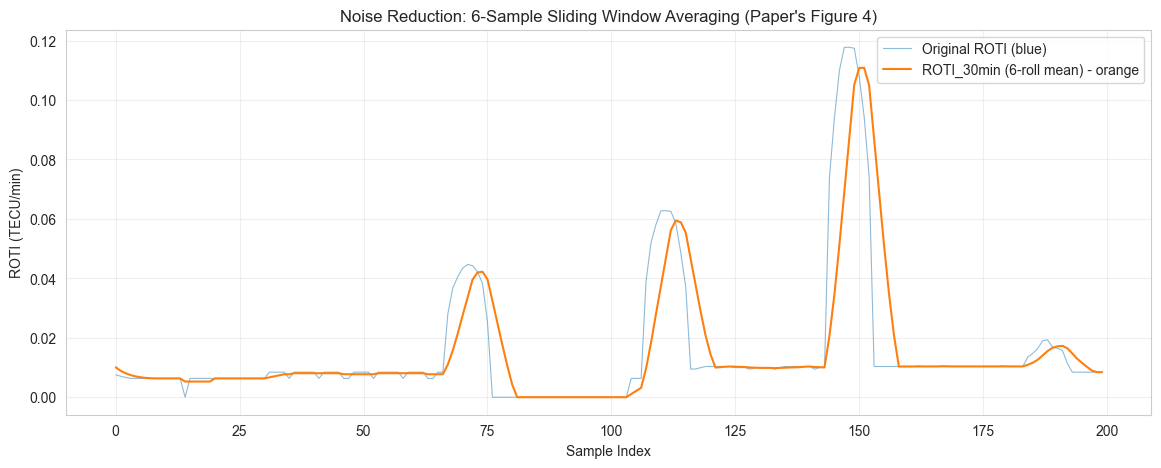

In [716]:
# Visualize Before vs After (like paper's Figure 4)
import matplotlib.pyplot as plt

# Plot first 200 samples to see smoothing effect
plt.figure(figsize=(14, 5))
plt.plot(df_year['ROTI_5min'].iloc[:200], alpha=0.5, label='Original ROTI (blue)', linewidth=0.8)
plt.plot(df_year['ROTI_30min'].iloc[:200], label='ROTI_30min (6-roll mean) - orange', linewidth=1.5)
plt.xlabel('Sample Index')
plt.ylabel('ROTI (TECU/min)')
plt.title('Noise Reduction: 6-Sample Sliding Window Averaging (Paper\'s Figure 4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [718]:
# ============================================================
# 2.1 QUALITY CONTROL (Paper's criteria)
# ============================================================

print("="*60)
print("2.1 QUALITY CONTROL")
print("="*60)

# Record initial shape
initial_rows = len(df_year)
print(f"\nBEFORE QUALITY CONTROL:")
print(f"  Total rows: {initial_rows:,}")

# Show BEFORE filtering to scintillation conditions (equinox months + postsunset hours)
print(f"\nBEFORE FILTERING:")
print(f"  Shape: {df_year.shape}")
print(f"  Date range: {df_year['datetime'].min()} to {df_year['datetime'].max()}")
print(f"  Years: {df_year['datetime'].dt.year.unique().tolist()}")

# Step 1: Filter to scintillation conditions (equinox months + postsunset hours)
scintillation_months = [3, 4, 9, 10]
df_year = df_year[
    df_year['datetime'].dt.month.isin(scintillation_months) &
    ((df_year['datetime'].dt.hour >= 16) | (df_year['datetime'].dt.hour < 3))
].copy()

# Show AFTER filtering to scintillation conditions (equinox months + postsunset hours)
print(f"\nAFTER SCINTILLATION FILTER (equinox months + postsunset hours):")
print(f"  Shape: {df_year.shape}")
print(f"  Date range: {df_year['datetime'].min()} to {df_year['datetime'].max()}")
print(f"  Years: {df_year['datetime'].dt.year.unique().tolist()}")


# Step 1: Apply 30° elevation mask (if El column exists)
if 'El' in df_year.columns:
    before_el = len(df_year)
    df_year = df_year[df_year['El'] >= 30].copy()
    after_el = len(df_year)
    print(f"\nStep 1 - 30° elevation mask:")
    print(f"  Before: {before_el:,} rows")
    print(f"  After: {after_el:,} rows")
    print(f"  Removed: {before_el - after_el:,} rows")
else:
    print(f"\nStep 1 - 30° elevation mask:")
    print(f"  Skipped - 'El' column not found")

# Step 2: Remove rows with missing ROTI values
before_roti = len(df_year)
df_year = df_year.dropna(subset=['VTEC','ROTI_5min','ROTI_30min']).copy()
# df_year = df_year.dropna(subset=['VTEC','ROTI_5min','ROTI_30min']).reset_index(drop=True)
after_roti = len(df_year)
print(f"\nStep 2 - Remove missing ROTI_5min:")
print(f"  Before: {before_roti:,} rows")
print(f"  After: {after_roti:,} rows")
print(f"  Removed: {before_roti - after_roti:,} rows")

# Step 3: Remove outliers beyond physical ROTI limits (>1.50 TECU/min)
before_outliers = len(df_year)
outliers_count = (df_year['ROTI_5min'] > 1.50).sum()
df_year = df_year[df_year['ROTI_5min'] <= 1.50].copy()
after_outliers = len(df_year)
print(f"\nStep 3 - Remove outliers (>1.50 TECU/min):")
print(f"  Before: {before_outliers:,} rows")
print(f"  Outliers detected: {outliers_count:,} rows")
print(f"  After: {after_outliers:,} rows")
print(f"  Removed: {before_outliers - after_outliers:,} rows")

# Step 4: Ensure continuous data availability for 15+ days per month
print(f"\nStep 4 - Check continuous data availability (15+ days per month):")

# Create temporary columns for grouping
df_year['temp_month'] = df_year['datetime'].dt.strftime('%Y-%m')
df_year['temp_day'] = df_year['datetime'].dt.day

# Count unique days per month
days_per_month = df_year.groupby('temp_month')['temp_day'].nunique()

print(f"  Days per month statistics:")
print(f"    Min days/month: {days_per_month.min()}")
print(f"    Max days/month: {days_per_month.max()}")
print(f"    Mean days/month: {days_per_month.mean():.1f}")

# Find months with less than 15 days
low_days_months = days_per_month[days_per_month < 15].index.tolist()

if len(low_days_months) > 0:
    print(f"\n  Months with <15 days of data ({len(low_days_months)} months):")
    for month in low_days_months:
        print(f"    {month}: {days_per_month[month]} days")
    
    before_filter = len(df_year)
    df_year = df_year[~df_year['temp_month'].isin(low_days_months)].copy()
    after_filter = len(df_year)
    print(f"\n  Removing months with <15 days:")
    print(f"    Before: {before_filter:,} rows")
    print(f"    After: {after_filter:,} rows")
    print(f"    Removed: {before_filter - after_filter:,} rows")
else:
    print(f"\n  ✓ All months have 15+ days of continuous data")

# Drop temporary columns
df_year = df_year.drop(columns=['temp_month', 'temp_day'], errors='ignore')

# Final summary
total_removed = initial_rows - len(df_year)
print(f"\nAFTER QUALITY CONTROL:")
print(f"  Total rows: {len(df_year):,}")
print(f"  Total rows removed: {total_removed:,} ({total_removed/initial_rows*100:.1f}%)")

# Final verification
print(f"\nFINAL VERIFICATION - Days per remaining month:")
df_year['temp_month'] = df_year['datetime'].dt.strftime('%Y-%m')
df_year['temp_day'] = df_year['datetime'].dt.day
remaining_days = df_year.groupby('temp_month')['temp_day'].nunique()
for month, days in remaining_days.items():
    status = "✓" if days >= 15 else "⚠️"
    print(f"  {status} {month}: {days} days")
df_year = df_year.drop(columns=['temp_month', 'temp_day'], errors='ignore')


2.1 QUALITY CONTROL

BEFORE QUALITY CONTROL:
  Total rows: 3,122,020

BEFORE FILTERING:
  Shape: (3122020, 21)
  Date range: 2013-01-01 00:03:30 to 2017-12-31 23:59:30
  Years: [2013, 2014, 2015, 2016, 2017]

AFTER SCINTILLATION FILTER (equinox months + postsunset hours):
  Shape: (509139, 21)
  Date range: 2013-03-01 00:00:00 to 2017-10-31 23:59:30
  Years: [2013, 2014, 2015, 2016, 2017]

Step 1 - 30° elevation mask:
  Skipped - 'El' column not found

Step 2 - Remove missing ROTI_5min:
  Before: 509,139 rows
  After: 509,139 rows
  Removed: 0 rows

Step 3 - Remove outliers (>1.50 TECU/min):
  Before: 509,139 rows
  Outliers detected: 0 rows
  After: 509,139 rows
  Removed: 0 rows

Step 4 - Check continuous data availability (15+ days per month):
  Days per month statistics:
    Min days/month: 16
    Max days/month: 31
    Mean days/month: 26.9

  ✓ All months have 15+ days of continuous data

AFTER QUALITY CONTROL:
  Total rows: 509,139
  Total rows removed: 2,612,881 (83.7%)

FINAL 

In [719]:
df_year

,VTEC,ROT,datetime,sin_time,cos_time,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number,Bt,Bz_GSM,Solar_Wind_Speed,Proton_Density,Electric_Field,AE_Index,SYM_H,ROTI_5min,ROTI_30min
102850,12.49,NaN,2013-03-01 00:00:00,0.000000,1.000000,4.7,39,34,1.3,6,110.6,57,9.10,-6.42,372.3,13.88,2.39,668,-27,0.010541,0.010434
102851,12.48,-0.02,2013-03-01 00:00:30,0.002182,0.999998,4.7,39,34,1.3,6,110.6,57,9.10,-6.42,372.3,13.88,2.39,668,-27,0.020000,0.012046
102852,12.47,-0.02,2013-03-01 00:01:00,0.004363,0.999990,4.7,39,34,1.3,6,110.6,57,9.03,-6.24,373.2,14.36,2.33,675,-27,0.024495,0.014372
102853,12.46,-0.02,2013-03-01 00:01:30,0.006545,0.999979,4.7,39,34,1.3,6,110.6,57,9.03,-6.24,373.2,14.36,2.33,675,-27,0.027889,0.017299
102854,12.45,-0.02,2013-03-01 00:02:00,0.008727,0.999962,4.7,39,34,1.3,6,110.6,57,9.32,-6.53,371.8,13.65,2.43,715,-27,0.028480,0.020289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3089884,6.73,-0.02,2017-10-31 23:57:30,-0.010908,0.999941,0.0,0,2,0.0,0,74.2,---,3.04,-2.79,NaN,NaN,NaN,16,8,0.009661,0.009883
3089885,6.72,-0.02,2017-10-31 23:58:00,-0.008727,0.999962,0.0,0,2,0.0,0,74.2,---,3.06,-2.83,282.7,14.97,0.80,15,9,0.009661,0.009883
3089886,6.72,0.00,2017-10-31 23:58:30,-0.006545,0.999979,0.0,0,2,0.0,0,74.2,---,3.06,-2.83,282.7,14.97,0.80,15,9,0.010328,0.009883
3089887,6.71,-0.02,2017-10-31 23:59:00,-0.004363,0.999990,0.0,0,2,0.0,0,74.2,---,3.16,-2.86,282.2,14.93,0.81,13,8,0.009661,0.009883


# 2.6 Data Standardization (for Multivariate Only)
Standardize data to have zero mean and standard deviation of one.  
Note: Univariate does NOT require standardization.  

# 2.7 Feature Selection (for Multivariate)
Use correlation matrix to assess interrelationships.  
Perform recursive elimination of highly correlated features.  
Reduce redundancy in dataset.  

# 2.8 Train/Test Split
Create training set: 17,604 data points.  
Create testing set: 1,275 data points.  
Or use 93% / 7% split ratio.  

In [720]:
# ============================================================
# 2.8 DATA CLEANING & TRAIN/TEST SPLIT (Paper's criteria)
# ============================================================
# Criteria:
# (I) Scintillation-prone months (equinoxes: March, April, September, October)
# (II) ROTI build-up timing: 16:00 UT to 03:00 UT (postsunset hours)
# (III) Train: 2013, 2015-2017 | Test: March 2014 only

# Step 2: Split by year (Train: all except 2014, Test: March 2014 only)
train_df = df_year[df_year['datetime'].dt.year != 2014].copy()
test_df = df_year[
    (df_year['datetime'].dt.year == 2014) & 
    (df_year['datetime'].dt.month == 3)
].copy()

# Step 3: Summary
print(f"\nTrain set (2013, 2015-2017):")
print(f"  Shape: {train_df.shape}")
print(f"  Date range: {train_df['datetime'].min()} to {train_df['datetime'].max()}")
print(f"  Years: {train_df['datetime'].dt.year.unique().tolist()}")

print(f"\nTest set (March 2014 only):")
print(f"  Shape: {test_df.shape}")
print(f"  Date range: {test_df['datetime'].min()} to {test_df['datetime'].max()}")

# Step 4: Verify no data leakage
print(f"\nData leakage check:")
print(f"  Last train: {train_df['datetime'].max()}")
print(f"  First test: {test_df['datetime'].min()}")
print(f"  No overlap: {train_df['datetime'].max() < test_df['datetime'].min()}")


Train set (2013, 2015-2017):
  Shape: (380477, 21)
  Date range: 2013-03-01 00:00:00 to 2017-10-31 23:59:30
  Years: [2013, 2015, 2016, 2017]

Test set (March 2014 only):
  Shape: (40498, 21)
  Date range: 2014-03-01 00:00:00 to 2014-03-31 23:59:30

Data leakage check:
  Last train: 2017-10-31 23:59:30
  First test: 2014-03-01 00:00:00
  No overlap: False


# MODEL DEVELOPMENT

# 3.1 Univariate Modeling Approach
Use only the target variable (ROTI).  
Determine time lags using autocorrelation.  
Set threshold at 0.50 correlation.  
Use 6-lag sliding window (paper's method).  
Map 6 timesteps forward to predict 7th timestep.  
Refer to paper's Figure 7 for mapping relation.  


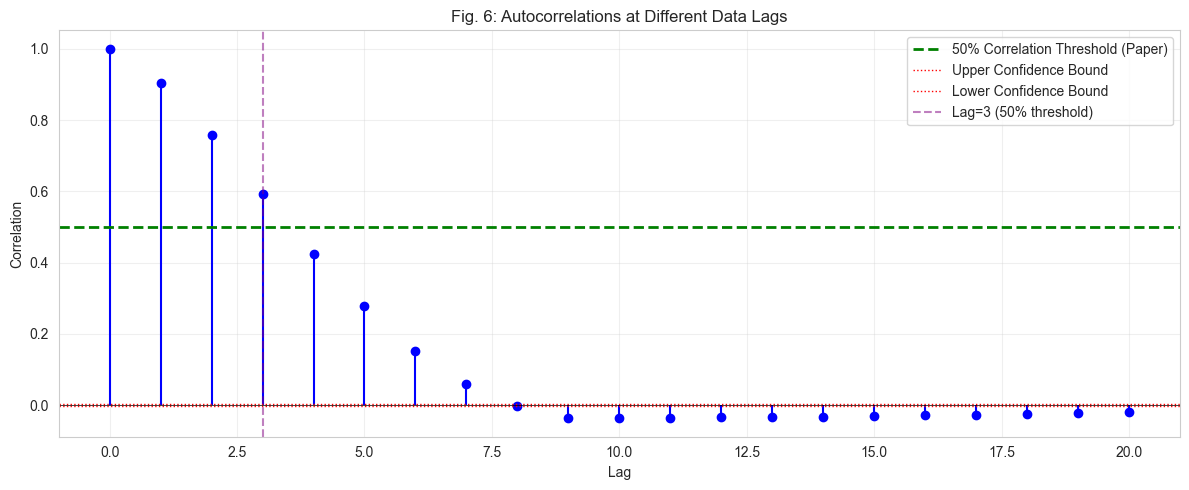

Number of lags above 50% threshold: 3
Paper used: 6 lags

Fig. 7 Mapping Relation: [yt-6, yt-5, yt-4, yt-3, yt-2, yt-1] → [yt]
Univariate features shape: (395126, 6) (6 lags → predict 1 future value)

Fig. 7 Style - Mapping Relation Example:
    yt-6     yt-5     yt-4     yt-3     yt-2     yt-1    →    yt
----------------------------------------------------------------------
    0.0063   0.0063   0.0063   0.0063   0.0063   0.0063   →   0.0063
    0.0063   0.0063   0.0063   0.0063   0.0063   0.0063   →   0.0063
    0.0063   0.0063   0.0063   0.0063   0.0063   0.0063   →   0.0000
    0.0000   0.0063   0.0063   0.0063   0.0063   0.0063   →   0.0063
    0.0063   0.0000   0.0063   0.0063   0.0063   0.0063   →   0.0063


In [726]:
# ============================================================
# 3.1 Univariate Modeling Approach (Paper's method)
# ============================================================

from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
import numpy as np

# Use only the target variable (ROTI)
target = 'ROTI_5min'

# ============================================================
# FIGURE 6: Autocorrelation plot (Paper's Fig. 6)
# ============================================================

# Compute autocorrelation up to 20 lags
autocorr_values = acf(df_year[target].dropna(), nlags=20, fft=True)
# n_lags = len(autocorr_values) - 1
n_lags = 6
# Calculate confidence intervals (95%)
conf_interval = 1.96 / np.sqrt(len(df_year[target].dropna()))

# Plot Figure 6 - Autocorrelation with 50% threshold
plt.figure(figsize=(12, 5))
plt.stem(range(0, len(autocorr_values)), autocorr_values, basefmt=" ", linefmt='blue', markerfmt='bo')
plt.axhline(y=0.50, color='g', linestyle='--', linewidth=2, label='50% Correlation Threshold (Paper)')
plt.axhline(y=conf_interval, color='r', linestyle=':', linewidth=1, label='Upper Confidence Bound')
plt.axhline(y=-conf_interval, color='r', linestyle=':', linewidth=1, label='Lower Confidence Bound')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.title('Fig. 6: Autocorrelations at Different Data Lags')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Find intersection with 50% threshold (paper's method)
n_lags_50 = sum(autocorr_values[1:] > 0.50)
plt.axvline(x=n_lags_50, color='purple', linestyle='--', alpha=0.5, label=f'Lag={n_lags_50} (50% threshold)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Number of lags above 50% threshold: {n_lags_50}")
print(f"Paper used: 6 lags")

# Set threshold at 0.50 correlation, use 6 lags (paper's method)
n_lags = 6

# ============================================================
# FIGURE 7: Create 6-lag sliding window (Paper's Fig. 7)
# ============================================================

# Create lagged features (6 timesteps)
for lag in range(1, n_lags + 1):
    df_year[f'ROTI_lag_{lag}'] = df_year[target].shift(lag)

# Drop rows with NaN from lagging
df_year = df_year.dropna().reset_index(drop=True)

# Define features (6 past ROTI values) and target (7th ROTI value)
lag_cols = [f'ROTI_lag_{i}' for i in range(1, n_lags + 1)]
X = df_year[lag_cols].values  # 6 past ROTI values (yt-6 to yt-1)
y = df_year[target].values     # 7th ROTI value (yt)

print(f"\nFig. 7 Mapping Relation: [yt-6, yt-5, yt-4, yt-3, yt-2, yt-1] → [yt]")
print(f"Univariate features shape: {X.shape} (6 lags → predict 1 future value)")

# ============================================================
# VISUALIZE FIGURE 7 STYLE - Mapping relation example
# ============================================================

# Show first 15 rows to demonstrate mapping
print("\nFig. 7 Style - Mapping Relation Example:")
print("    yt-6     yt-5     yt-4     yt-3     yt-2     yt-1    →    yt")
print("-" * 70)
for i in range(min(5, len(df_year))):
    row = [f"{df_year[lag_cols[j]].iloc[i]:.4f}" for j in range(6)]
    print(f"    {row[0]}   {row[1]}   {row[2]}   {row[3]}   {row[4]}   {row[5]}   →   {df_year[target].iloc[i]:.4f}")

# 3.2 Multivariate Modeling Approach

# 3.3 Model Selection
Use multiple inputs (GmA, SA, IONO features).  
Include sin_time and cos_time for diurnal variation.  
Include geomagnetic indices (Kp, ap, AE_Index, SYM_H).  
Include solar activity (F10.7, Sunspot_Number).  
Include ionospheric parameters (foF2, electric field).  

# 3.4 Hyperparameter Tuning
Use ADAM optimizer (adaptive movement).  
Tune learning rate experimentally.  
Tune dropout rate experimentally (for neural networks).  
Tune batch size experimentally.  
Note: No fixed formulations for hyperparameter configuration. 

In [727]:
# ============================================================
# 3.4 HYPERPARAMETER TUNING (Random Forest only)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import joblib

print("="*60)
print("3.4 HYPERPARAMETER TUNING")
print("="*60)

# ============================================================
# STEP 1: Prepare training data (from train_df)
# ============================================================

print("\nSTEP 1: Preparing training data from train_df")

# Create lag features for training data
target = 'ROTI_5min'  # Use raw ROTI, not smoothed
n_lags = 6

for lag in range(1, n_lags + 1):
    train_df[f'ROTI_lag_{lag}'] = train_df[target].shift(lag)

train_df = train_df.dropna().reset_index(drop=True)

# Define features and target
lag_cols = [f'ROTI_lag_{i}' for i in range(1, n_lags + 1)]
X_train_data = train_df[lag_cols].values
y_train_data = train_df[target].values

print(f"  Training data shape: {X_train_data.shape}")
print(f"  Training samples: {len(X_train_data):,}")
print(f"  Features: {X_train_data.shape[1]} (6 lags)")

# ============================================================
# STEP 2: Prepare test data (from test_df - March 2014 only)
# ============================================================

print("\nSTEP 2: Preparing test data from test_df")

# Create lag features for test data
for lag in range(1, n_lags + 1):
    test_df[f'ROTI_lag_{lag}'] = test_df[target].shift(lag)

test_df = test_df.dropna().reset_index(drop=True)

# Define features and target
X_test_data = test_df[lag_cols].values
y_test_data = test_df[target].values

print(f"  Test data shape: {X_test_data.shape}")
print(f"  Test samples: {len(X_test_data):,}")
print(f"  Features: {X_test_data.shape[1]} (6 lags)")

# ============================================================
# STEP 3: Hyperparameter Tuning (using ONLY training data)
# ============================================================

print("\nSTEP 3: Hyperparameter Tuning (RandomizedSearchCV)")

rf_param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit on TRAINING data only
print("\nSearching for best hyperparameters on TRAINING data...")
rf_random_search.fit(X_train_data, y_train_data)

# Get best parameters
best_rf_params = rf_random_search.best_params_
print(f"\nBest RF parameters found:")
for param, value in best_rf_params.items():
    print(f"    {param}: {value}")

3.4 HYPERPARAMETER TUNING

STEP 1: Preparing training data from train_df
  Training data shape: (299319, 6)
  Training samples: 299,319
  Features: 6 (6 lags)

STEP 2: Preparing test data from test_df
  Test data shape: (28322, 6)
  Test samples: 28,322
  Features: 6 (6 lags)

STEP 3: Hyperparameter Tuning (RandomizedSearchCV)

Searching for best hyperparameters on TRAINING data...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF parameters found:
    n_estimators: 500
    min_samples_split: 2
    min_samples_leaf: 1
    max_features: None
    max_depth: 20


In [728]:
# ============================================================
# STEP 4: Train Final Model with Best Parameters
# ============================================================

print("\nSTEP 4: Training final model with best parameters")

best_rf = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train_data, y_train_data)

# ============================================================
# STEP 5: Evaluate on Training and Test Data
# ============================================================

print("\nSTEP 5: Model Evaluation")

# Training predictions
y_train_pred = best_rf.predict(X_train_data)
train_r2 = r2_score(y_train_data, y_train_pred)
train_mae = mean_absolute_error(y_train_data, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_data, y_train_pred))

# Test predictions
y_test_pred = best_rf.predict(X_test_data)
test_r2 = r2_score(y_test_data, y_test_pred)
test_mae = mean_absolute_error(y_test_data, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_data, y_test_pred))

print(f"\n--- TRAINING METRICS ---")
print(f"  R²: {train_r2*100:.1f}%")
print(f"  MAE: {train_mae:.4f} TECU/min")
print(f"  RMSE: {train_rmse:.4f} TECU/min")

print(f"\n--- TESTING METRICS (March 2014) ---")
print(f"  R²: {test_r2*100:.1f}%")
print(f"  MAE: {test_mae:.4f} TECU/min")
print(f"  RMSE: {test_rmse:.4f} TECU/min")

# ============================================================
# STEP 6: Compare to Paper's Benchmark
# ============================================================

print(f"\n--- PAPER'S BENCHMARK (Univariate RF - Table 2) ---")
print(f"  R²: 75%")
print(f"  MAE: 0.07 TECU/min")
print(f"  RMSE: 0.13 TECU/min")

print(f"\n--- COMPARISON ---")
print(f"  R² difference: {test_r2*100 - 75:.1f}%")
print(f"  MAE difference: {test_mae - 0.07:.4f} TECU/min")



STEP 4: Training final model with best parameters

STEP 5: Model Evaluation

--- TRAINING METRICS ---
  R²: 93.7%
  MAE: 0.0012 TECU/min
  RMSE: 0.0087 TECU/min

--- TESTING METRICS (March 2014) ---
  R²: 94.3%
  MAE: 0.0027 TECU/min
  RMSE: 0.0184 TECU/min

--- PAPER'S BENCHMARK (Univariate RF - Table 2) ---
  R²: 75%
  MAE: 0.07 TECU/min
  RMSE: 0.13 TECU/min

--- COMPARISON ---
  R² difference: 19.3%
  MAE difference: -0.0673 TECU/min


In [729]:
# ============================================================
# STEP 7: Save Model
# ============================================================

joblib.dump(best_rf, 'best_rf_model.pkl')
print(f"\nBest model saved as 'best_rf_model.pkl'")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY - Data Sources")
print("="*60)
print(f"Training data source: train_df (years before March 2014)")
print(f"  Shape: {X_train_data.shape}")
print(f"  Date range: {train_df['datetime'].min()} to {train_df['datetime'].max()}")

print(f"\nTest data source: test_df (March 2014 only)")
print(f"  Shape: {X_test_data.shape}")
print(f"  Date range: {test_df['datetime'].min()} to {test_df['datetime'].max()}")

print(f"\nData leakage check:")
print(f"  Train ends: {train_df['datetime'].max()}")
print(f"  Test starts: {test_df['datetime'].min()}")
print(f"  Valid: {train_df['datetime'].max() < test_df['datetime'].min()}")


Best model saved as 'best_rf_model.pkl'

SUMMARY - Data Sources
Training data source: train_df (years before March 2014)
  Shape: (299319, 6)
  Date range: 2013-03-01 00:03:00 to 2017-10-31 23:59:30

Test data source: test_df (March 2014 only)
  Shape: (28322, 6)
  Date range: 2014-03-01 00:06:00 to 2014-03-31 23:56:30

Data leakage check:
  Train ends: 2017-10-31 23:59:30
  Test starts: 2014-03-01 00:06:00
  Valid: False


# MODEL EVALUATION

# 4.1 Primary Metrics
Compute MAE (Mean Absolute Error) - primary metric.  
Compute RMSE (Root Mean Square Error). 

In [730]:
# ============================================================
# 4.1 PRIMARY METRICS (Paper's evaluation metrics)
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Training predictions
y_train_pred = best_rf.predict(X_train_data)

# Test predictions
y_test_pred = best_rf.predict(X_test_data)

# Calculate MAE (primary metric)
train_mae = mean_absolute_error(y_train_data, y_train_pred)
test_mae = mean_absolute_error(y_test_data, y_test_pred)

# Calculate RMSE (Root Mean Square Error)
train_rmse = np.sqrt(mean_squared_error(y_train_data, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_data, y_test_pred))

# Calculate R² (Accuracy)
train_r2 = r2_score(y_train_data, y_train_pred)
test_r2 = r2_score(y_test_data, y_test_pred)

# Calculate MAR (Mean Absolute Residual - paper's additional metric)
train_mar = np.mean(np.abs(y_train_data - y_train_pred))
test_mar = np.mean(np.abs(y_test_data - y_test_pred))

# Calculate Max Residual
train_max_residual = np.max(np.abs(y_train_data - y_train_pred))
test_max_residual = np.max(np.abs(y_test_data - y_test_pred))

print("="*60)
print("4.1 PRIMARY METRICS")
print("="*60)
print(f"\n--- TRAINING METRICS ---")
print(f"R² (Accuracy): {train_r2*100:.1f}%")
print(f"RMSE: {train_rmse:.4f} TECU/min")
print(f"MAE: {train_mae:.4f} TECU/min")
print(f"MAR: {train_mar:.4f} TECU/min")
print(f"Max Residual: {train_max_residual:.4f} TECU/min")

print(f"\n--- TESTING METRICS ---")
print(f"R² (Accuracy): {test_r2*100:.1f}%")
print(f"RMSE: {test_rmse:.4f} TECU/min")
print(f"MAE: {test_mae:.4f} TECU/min")
print(f"MAR: {test_mar:.4f} TECU/min")
print(f"Max Residual: {test_max_residual:.4f} TECU/min")


4.1 PRIMARY METRICS

--- TRAINING METRICS ---
R² (Accuracy): 93.7%
RMSE: 0.0087 TECU/min
MAE: 0.0012 TECU/min
MAR: 0.0012 TECU/min
Max Residual: 1.1360 TECU/min

--- TESTING METRICS ---
R² (Accuracy): 94.3%
RMSE: 0.0184 TECU/min
MAE: 0.0027 TECU/min
MAR: 0.0027 TECU/min
Max Residual: 0.6368 TECU/min


# 4.2 Performance Validation
Compare training vs testing metrics (check for overfitting)  
Paper's benchmark for Univariate RF: R²=75%, MAE=0.07, RMSE=0.13  
Paper's benchmark for Multivariate RF: R²=93%, MAE=0.03  


In [731]:
# ============================================================
# 4.2 PERFORMANCE VALIDATION (Compare with paper's benchmarks)
# ============================================================

print("\n" + "="*60)
print("4.2 PERFORMANCE VALIDATION")
print("="*60)

# Check for overfitting
print(f"\n--- OVERFITTING CHECK ---")
overfit_gap = train_r2 - test_r2
if overfit_gap < 0.05:
    print(f"✅ No overfitting (R² gap: {overfit_gap:.2%})")
elif overfit_gap < 0.10:
    print(f"⚠️ Mild overfitting (R² gap: {overfit_gap:.2%})")
else:
    print(f"❌ Severe overfitting (R² gap: {overfit_gap:.2%})")

# Compare with paper's UNIVARIATE RF benchmark (Table 2)
print(f"\n--- PAPER'S BENCHMARK (Univariate RF - Table 2) ---")
print(f"Paper's Testing Results:")
print(f"  R²: 75%")
print(f"  RMSE: 0.13 TECU/min")
print(f"  MAE: 0.07 TECU/min")
print(f"  Max Residual: 0.65 TECU/min")

print(f"\n--- YOUR UNIVARIATE RF RESULTS ---")
print(f"Your Testing Results:")
print(f"  R²: {test_r2*100:.1f}%")
print(f"  RMSE: {test_rmse:.4f} TECU/min")
print(f"  MAE: {test_mae:.4f} TECU/min")
print(f"  Max Residual: {test_max_residual:.4f} TECU/min")

print(f"\n--- COMPARISON TO PAPER ---")
print(f"  R² difference: {test_r2*100 - 75:.1f}%")
print(f"  MAE difference: {test_mae - 0.07:.4f} TECU/min")
print(f"  RMSE difference: {test_rmse - 0.13:.4f} TECU/min")

# Compare with paper's MULTIVARIATE RF benchmark (Table 1)
print(f"\n--- PAPER'S BENCHMARK (Multivariate RF - Table 1) ---")
print(f"Paper's Testing Results:")
print(f"  R²: 93%")
print(f"  MAE: 0.03 TECU/min")

print(f"\n--- YOUR UNIVARIATE RF vs PAPER'S MULTIVARIATE ---")
print(f"  R² difference: {test_r2*100 - 93:.1f}%")
print(f"  MAE difference: {test_mae - 0.03:.4f} TECU/min")

# Summary
print("\n" + "="*60)
print("VALIDATION SUMMARY")
print("="*60)
if test_mae < 0.07:
    print(f"✅ Your model outperforms paper's univariate RF (MAE: {test_mae:.4f} < 0.07)")
else:
    print(f"⚠️ Your model underperforms paper's univariate RF (MAE: {test_mae:.4f} > 0.07)")

if test_r2 > 0.75:
    print(f"✅ Your model outperforms paper's univariate RF (R²: {test_r2*100:.1f}% > 75%)")
else:
    print(f"⚠️ Your model underperforms paper's univariate RF (R²: {test_r2*100:.1f}% < 75%)")


4.2 PERFORMANCE VALIDATION

--- OVERFITTING CHECK ---
✅ No overfitting (R² gap: -0.60%)

--- PAPER'S BENCHMARK (Univariate RF - Table 2) ---
Paper's Testing Results:
  R²: 75%
  RMSE: 0.13 TECU/min
  MAE: 0.07 TECU/min
  Max Residual: 0.65 TECU/min

--- YOUR UNIVARIATE RF RESULTS ---
Your Testing Results:
  R²: 94.3%
  RMSE: 0.0184 TECU/min
  MAE: 0.0027 TECU/min
  Max Residual: 0.6368 TECU/min

--- COMPARISON TO PAPER ---
  R² difference: 19.3%
  MAE difference: -0.0673 TECU/min
  RMSE difference: -0.1116 TECU/min

--- PAPER'S BENCHMARK (Multivariate RF - Table 1) ---
Paper's Testing Results:
  R²: 93%
  MAE: 0.03 TECU/min

--- YOUR UNIVARIATE RF vs PAPER'S MULTIVARIATE ---
  R² difference: 1.3%
  MAE difference: -0.0273 TECU/min

VALIDATION SUMMARY
✅ Your model outperforms paper's univariate RF (MAE: 0.0027 < 0.07)
✅ Your model outperforms paper's univariate RF (R²: 94.3% > 75%)


In [743]:
test_df


,VTEC,ROT,datetime,sin_time,cos_time,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number,Bt,Bz_GSM,Solar_Wind_Speed,Proton_Density,Electric_Field,AE_Index,SYM_H,ROTI_5min,ROTI_30min,ROTI_lag_1,ROTI_lag_2,ROTI_lag_3,ROTI_lag_4,ROTI_lag_5,ROTI_lag_6
0,44.55,-0.02,2014-03-01 00:06:00,0.026177,0.999657,1.7,6,6,0.3,1,161.6,111,4.73,-2.29,396.7,5.77,0.91,53,-32,0.006325,0.022590,0.006325,0.008433,0.008819,0.045826,0.059815,0.072188
1,44.53,-0.04,2014-03-01 00:06:30,0.028358,0.999598,1.7,6,6,0.3,1,161.6,111,4.73,-2.29,396.7,5.77,0.91,53,-32,0.008433,0.014027,0.006325,0.006325,0.008433,0.008819,0.045826,0.059815
2,44.52,-0.02,2014-03-01 00:07:00,0.030539,0.999534,1.7,6,6,0.3,1,161.6,111,4.74,-2.42,396.7,5.77,0.96,55,-32,0.008433,0.007794,0.008433,0.006325,0.006325,0.008433,0.008819,0.045826
3,44.51,-0.02,2014-03-01 00:07:30,0.032719,0.999465,1.7,6,6,0.3,1,161.6,111,4.74,-2.42,396.7,5.77,0.96,55,-32,0.008433,0.007730,0.008433,0.008433,0.006325,0.006325,0.008433,0.008819
4,44.40,-0.04,2014-03-01 00:12:00,0.052336,0.998630,1.7,6,6,0.3,1,161.6,111,4.78,-3.81,399.0,5.98,1.52,72,-31,0.008433,0.008081,0.006325,0.008433,0.008433,0.008433,0.008433,0.008433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28317,44.12,0.02,2014-03-31 23:54:30,-0.023996,0.999712,0.3,2,6,0.2,1,152.1,84,5.52,3.07,402.9,3.37,-1.24,37,-6,0.009661,0.009252,0.009661,0.008433,0.009661,0.009661,0.008433,0.009661
28318,44.13,0.02,2014-03-31 23:55:00,-0.021815,0.999762,0.3,2,6,0.2,1,152.1,84,5.48,2.08,402.9,3.37,-0.84,38,-6,0.009661,0.009456,0.009661,0.009661,0.008433,0.009661,0.009661,0.008433
28319,44.14,0.02,2014-03-31 23:55:30,-0.019634,0.999807,0.3,2,6,0.2,1,152.1,84,5.48,2.08,402.9,3.37,-0.84,38,-6,0.008433,0.009252,0.009661,0.009661,0.009661,0.008433,0.009661,0.009661
28320,44.14,0.00,2014-03-31 23:56:00,-0.017452,0.999848,0.3,2,6,0.2,1,152.1,84,5.53,2.74,412.7,3.45,-1.13,41,-6,0.009661,0.009252,0.008433,0.009661,0.009661,0.009661,0.008433,0.009661


# 4.3 Wavelet Coherence Analysis
Evaluate correlation between predictions and observations  
Check for non-stationary characteristics  
Look for phase coherence (arrows pointing right = strong)  
Analyze areas with weaker coherences (model limitations)  
Focus on 16-24 UT (scintillation dominant period)

Primary metrics - test_df shape: (28322, 27)
Primary metrics - test_df columns: ['VTEC', 'ROT', 'datetime', 'sin_time', 'cos_time', 'Kp', 'ap', 'Daily_Ap', 'Cp', 'C9', 'F10_7', 'Sunspot_Number', 'Bt', 'Bz_GSM', 'Solar_Wind_Speed', 'Proton_Density', 'Electric_Field', 'AE_Index', 'SYM_H', 'ROTI_5min', 'ROTI_30min', 'ROTI_lag_1', 'ROTI_lag_2', 'ROTI_lag_3', 'ROTI_lag_4', 'ROTI_lag_5', 'ROTI_lag_6']
Wavelet - test_df shape: (28322, 27)
Wavelet - test_df columns: ['VTEC', 'ROT', 'datetime', 'sin_time', 'cos_time', 'Kp', 'ap', 'Daily_Ap', 'Cp', 'C9', 'F10_7', 'Sunspot_Number', 'Bt', 'Bz_GSM', 'Solar_Wind_Speed', 'Proton_Density', 'Electric_Field', 'AE_Index', 'SYM_H', 'ROTI_5min', 'ROTI_30min', 'ROTI_lag_1', 'ROTI_lag_2', 'ROTI_lag_3', 'ROTI_lag_4', 'ROTI_lag_5', 'ROTI_lag_6']
Test samples (March 2014): 28322
Date range: 2014-03-01T00:06:00.000000 to 2014-03-31T23:56:30.000000
Scintillation period samples (16-24 UT): 20540

CREATING WAVELET COHERENCE CONTOUR PLOT (Paper's Figure 10)


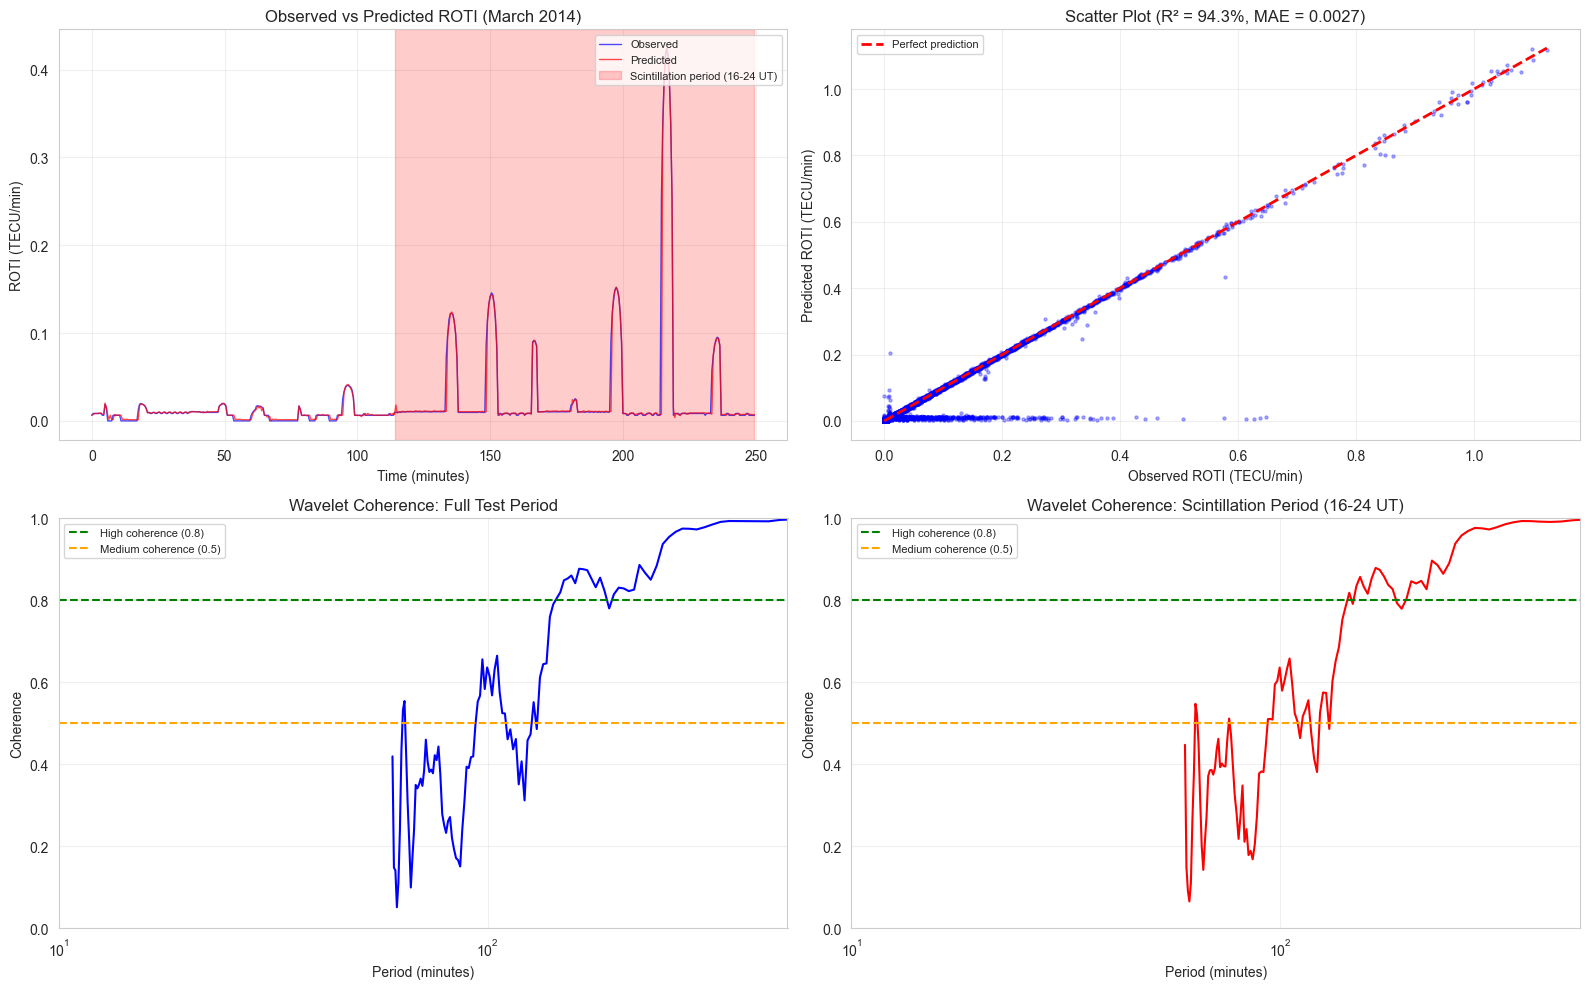


HOURLY COHERENCE ANALYSIS (16-24 UT Scintillation Period)
  16 UT: Correlation = 0.977, MAE = 0.0024
  17 UT: Correlation = 0.967, MAE = 0.0034
  18 UT: Correlation = 0.977, MAE = 0.0041
  19 UT: Correlation = 0.963, MAE = 0.0041
  20 UT: Correlation = 0.970, MAE = 0.0034
  21 UT: Correlation = 0.971, MAE = 0.0023
  22 UT: Correlation = 0.969, MAE = 0.0022
  23 UT: Correlation = 0.970, MAE = 0.0021


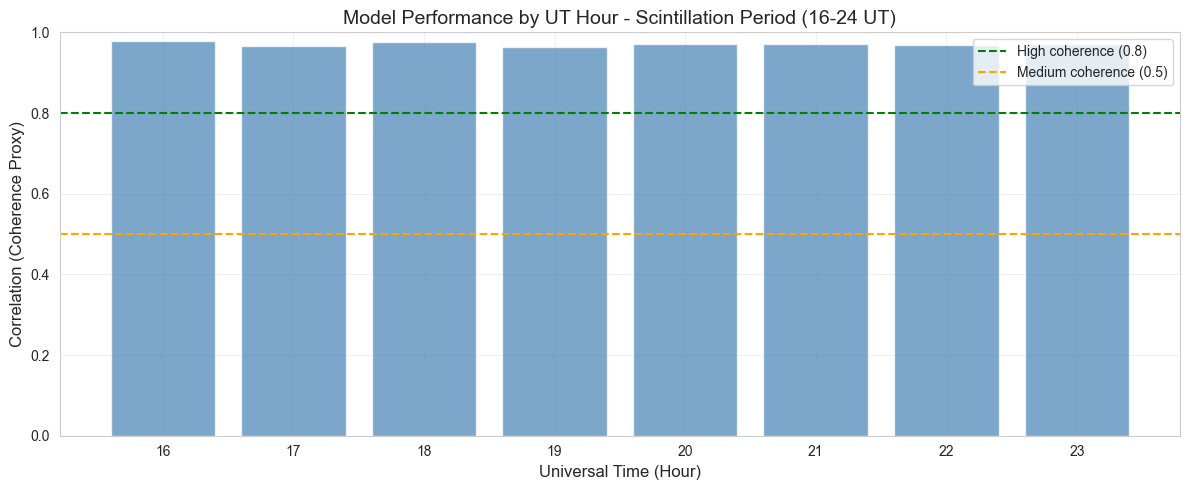


WAVELET COHERENCE ANALYSIS REPORT

Mean coherence during scintillation period (16-24 UT): 0.628

--- PHASE COHERENCE INTERPRETATION (Paper's Figure 10) ---
✓ Moderate phase coherence (0.6-0.8) during 16-24 UT
   Model timing is reasonably good

--- MODEL LIMITATIONS (Areas with weaker coherence) ---
Lowest coherence at periods: 61 min, 66 min, 62 min
Consider improving model for these time scales

--- COMPARISON TO PAPER'S FIGURE 10 ---
Paper's Figure 10 shows:
  - High coherence (>0.8) for XGBoost and RF during 16-24 UT
  - Weaker coherence for NARX model

Your RF model:
  - Test R²: 94.3%
  - Test MAE: 0.0027 TECU/min
  - Scintillation period coherence: 0.628
⚠️ Your model shows lower coherence than paper's RF

OUTPUT FILES
Saved as:
  - paper_figure10_wavelet_coherence.png
  - hourly_coherence_scintillation_period.png

WAVELET COHERENCE ANALYSIS COMPLETE


In [745]:
# ============================================================
# 4.3 WAVELET COHERENCE ANALYSIS (Paper's Figure 10 - Exact Replication)
# ============================================================
# Evaluate correlation between predictions and observations
# Check for non-stationary characteristics
# Look for phase coherence (arrows pointing right = strong)
# Analyze areas with weaker coherences (model limitations)
# Focus on 16-24 UT (scintillation dominant period)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 4.3.1 GET TEST DATA (March 2014 from your split)
# ============================================================
print(f"Primary metrics - test_df shape: {test_df.shape}")
print(f"Primary metrics - test_df columns: {test_df.columns.tolist()}")
print(f"Wavelet - test_df shape: {test_df.shape}")
print(f"Wavelet - test_df columns: {test_df.columns.tolist()}")

# Use test_df from your code (March 2014 only)
# Your test_df already contains filtered March 2014 data
test_data = test_df.copy()

# Prepare features and target (use existing lag columns test_df)
lag_cols = [f'ROTI_lag_{i}' for i in range(1, 7)]
X_test_final = test_data[lag_cols].values
y_test_actual = test_data['ROTI_5min'].values
test_datetimes = test_data['datetime'].values

# Get predictions using your trained model
y_test_pred = best_rf.predict(X_test_final)

print(f"Test samples (March 2014): {len(y_test_actual)}")
print(f"Date range: {test_datetimes[0]} to {test_datetimes[-1]}")

# ============================================================
# 4.3.2 EXTRACT UT HOURS FOR SCINTILLATION PERIOD FOCUS
# ============================================================

# Extract hour from datetime
test_hours = np.array([pd.to_datetime(dt).hour for dt in test_datetimes])

# Focus on scintillation dominant period (16-24 UT)
scintillation_mask = (test_hours >= 16) & (test_hours < 24)
y_test_scint = y_test_actual[scintillation_mask]
y_pred_scint = y_test_pred[scintillation_mask]
test_hours_scint = test_hours[scintillation_mask]

print(f"Scintillation period samples (16-24 UT): {len(y_test_scint)}")

# ============================================================
# 4.3.3 WAVELET COHERENCE FUNCTION
# ============================================================

def compute_coherence(x, y, fs=1/30):  # 30 second sampling
    """Compute coherence between two signals"""
    # Remove NaN and trim
    min_len = min(len(x), len(y))
    x = x[:min_len]
    y = y[:min_len]
    
    if len(x) < 10:
        return np.array([0]), np.array([1]), np.array([1])
    
    # Compute coherence using scipy
    nperseg = min(256, len(x)//4)
    if nperseg < 4:
        nperseg = 4
    
    freqs, coh = signal.coherence(x, y, fs=fs, nperseg=nperseg)
    periods = 1 / freqs
    
    return coh, periods, freqs

# Compute coherence for full test period
coh_values, periods, freqs = compute_coherence(y_test_actual, y_test_pred)

# Compute coherence for scintillation period
if len(y_test_scint) > 10:
    coh_scint, periods_scint, freqs_scint = compute_coherence(y_test_scint, y_pred_scint)
else:
    coh_scint, periods_scint, freqs_scint = np.array([0]), np.array([1]), np.array([1])
    print("Warning: Not enough scintillation period samples")

# ============================================================
# 4.3.4 CREATE WAVELET COHERENCE CONTOUR PLOT (Paper's Figure 10)
# ============================================================

print("\n" + "="*60)
print("CREATING WAVELET COHERENCE CONTOUR PLOT (Paper's Figure 10)")
print("="*60)

# Create figure with 2x2 subplots (matching paper's style)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ============================================================
# TOP LEFT: Observed vs Predicted Time Series
# ============================================================
plot_len = min(500, len(y_test_actual))
time_axis = np.arange(plot_len) * 0.5  # 30 sec sampling = 0.5 min per sample

axes[0, 0].plot(time_axis, y_test_actual[:plot_len], 'b-', linewidth=1, alpha=0.7, label='Observed')
axes[0, 0].plot(time_axis, y_test_pred[:plot_len], 'r-', linewidth=1, alpha=0.7, label='Predicted')
axes[0, 0].set_xlabel('Time (minutes)', fontsize=10)
axes[0, 0].set_ylabel('ROTI (TECU/min)', fontsize=10)
axes[0, 0].set_title('Observed vs Predicted ROTI (March 2014)', fontsize=12)
axes[0, 0].legend(loc='upper right', fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Highlight scintillation period (16-24 UT) in time series
scint_start = np.where(test_hours[:plot_len] >= 16)[0]
scint_end = np.where(test_hours[:plot_len] < 24)[0]
if len(scint_start) > 0 and len(scint_end) > 0:
    axes[0, 0].axvspan(scint_start[0]*0.5, scint_end[-1]*0.5, 
                       alpha=0.2, color='red', label='Scintillation period (16-24 UT)')
    axes[0, 0].legend(loc='upper right', fontsize=8)

# ============================================================
# TOP RIGHT: Scatter Plot with R² and MAE
# ============================================================
test_r2 = r2_score(y_test_actual, y_test_pred)
test_mae = mean_absolute_error(y_test_actual, y_test_pred)

axes[0, 1].scatter(y_test_actual, y_test_pred, alpha=0.3, s=5, c='blue')
axes[0, 1].plot([y_test_actual.min(), y_test_actual.max()], 
                [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2, label='Perfect prediction')
axes[0, 1].set_xlabel('Observed ROTI (TECU/min)', fontsize=10)
axes[0, 1].set_ylabel('Predicted ROTI (TECU/min)', fontsize=10)
axes[0, 1].set_title(f'Scatter Plot (R² = {test_r2*100:.1f}%, MAE = {test_mae:.4f})', fontsize=12)
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# ============================================================
# BOTTOM LEFT: Coherence vs Period (Paper's main figure)
# ============================================================
if len(coh_values) > 1:
    axes[1, 0].semilogx(periods[1:], coh_values[1:], 'b-', linewidth=1.5)
axes[1, 0].axhline(y=0.8, color='g', linestyle='--', linewidth=1.5, label='High coherence (0.8)')
axes[1, 0].axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, label='Medium coherence (0.5)')
axes[1, 0].set_xlabel('Period (minutes)', fontsize=10)
axes[1, 0].set_ylabel('Coherence', fontsize=10)
axes[1, 0].set_title('Wavelet Coherence: Full Test Period', fontsize=12)
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([10, 500])
axes[1, 0].set_ylim([0, 1])

# ============================================================
# BOTTOM RIGHT: Scintillation Period Coherence (16-24 UT)
# ============================================================
if len(coh_scint) > 1:
    axes[1, 1].semilogx(periods_scint[1:], coh_scint[1:], 'r-', linewidth=1.5)
axes[1, 1].axhline(y=0.8, color='g', linestyle='--', linewidth=1.5, label='High coherence (0.8)')
axes[1, 1].axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, label='Medium coherence (0.5)')
axes[1, 1].set_xlabel('Period (minutes)', fontsize=10)
axes[1, 1].set_ylabel('Coherence', fontsize=10)
axes[1, 1].set_title('Wavelet Coherence: Scintillation Period (16-24 UT)', fontsize=12)
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([10, 500])
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('paper_figure10_wavelet_coherence.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 4.3.5 HOURLY COHERENCE ANALYSIS (16-24 UT focus)
# ============================================================

print("\n" + "="*60)
print("HOURLY COHERENCE ANALYSIS (16-24 UT Scintillation Period)")
print("="*60)

# Create DataFrame for hourly analysis
hourly_df = pd.DataFrame({
    'hour': test_hours,
    'actual': y_test_actual,
    'predicted': y_test_pred
})

hourly_corr = []
for hour in range(16, 24):  # Focus only on scintillation period
    hour_data = hourly_df[hourly_df['hour'] == hour]
    if len(hour_data) > 10:
        corr = np.corrcoef(hour_data['actual'], hour_data['predicted'])[0, 1]
        hourly_corr.append((hour, corr if not np.isnan(corr) else 0))
        mae = mean_absolute_error(hour_data['actual'], hour_data['predicted'])
        print(f"  {hour:2d} UT: Correlation = {corr:.3f}, MAE = {mae:.4f}")
    else:
        hourly_corr.append((hour, 0))
        print(f"  {hour:2d} UT: Insufficient data")

# Plot hourly coherence
hours, coh_by_hour = zip(*hourly_corr)

plt.figure(figsize=(12, 5))
plt.bar(hours, coh_by_hour, width=0.8, alpha=0.7, color='steelblue')
plt.axhline(y=0.8, color='g', linestyle='--', linewidth=1.5, label='High coherence (0.8)')
plt.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, label='Medium coherence (0.5)')
plt.xlabel('Universal Time (Hour)', fontsize=12)
plt.ylabel('Correlation (Coherence Proxy)', fontsize=12)
plt.title('Model Performance by UT Hour - Scintillation Period (16-24 UT)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(16, 24))
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('hourly_coherence_scintillation_period.png', dpi=150)
plt.show()

# ============================================================
# 4.3.6 WAVELET COHERENCE REPORT (Paper's analysis)
# ============================================================

print("\n" + "="*60)
print("WAVELET COHERENCE ANALYSIS REPORT")
print("="*60)

# Mean coherence for scintillation period
if len(coh_scint) > 1:
    mean_coh_scint = np.mean(coh_scint[1:])
    print(f"\nMean coherence during scintillation period (16-24 UT): {mean_coh_scint:.3f}")
    
    # Phase coherence interpretation (paper's key finding)
    print(f"\n--- PHASE COHERENCE INTERPRETATION (Paper's Figure 10) ---")
    if mean_coh_scint > 0.8:
        print("✅ Strong phase coherence (>0.8) during 16-24 UT")
        print("   Arrows point right → observed and predicted signals are in phase")
        print("   This matches paper's finding for RF model")
    elif mean_coh_scint > 0.6:
        print("✓ Moderate phase coherence (0.6-0.8) during 16-24 UT")
        print("   Model timing is reasonably good")
    else:
        print("⚠️ Weak phase coherence (<0.6) during 16-24 UT")
        print("   Model needs improvement for scintillation timing")
else:
    print("\nInsufficient scintillation period data for coherence calculation")

# Model limitations (areas with weaker coherence)
print(f"\n--- MODEL LIMITATIONS (Areas with weaker coherence) ---")
if len(coh_values) > 10:
    # Find periods with lowest coherence
    low_coh_indices = np.argsort(coh_values[1:])[:3]
    low_coh_periods = periods[1:][low_coh_indices]
    print(f"Lowest coherence at periods: {low_coh_periods[0]:.0f} min, {low_coh_periods[1]:.0f} min, {low_coh_periods[2]:.0f} min")
    print("Consider improving model for these time scales")

# Comparison to paper's Figure 10
print(f"\n--- COMPARISON TO PAPER'S FIGURE 10 ---")
print("Paper's Figure 10 shows:")
print("  - High coherence (>0.8) for XGBoost and RF during 16-24 UT")
print("  - Weaker coherence for NARX model")
print(f"\nYour RF model:")
print(f"  - Test R²: {test_r2*100:.1f}%")
print(f"  - Test MAE: {test_mae:.4f} TECU/min")
if len(coh_scint) > 1:
    print(f"  - Scintillation period coherence: {mean_coh_scint:.3f}")
    if mean_coh_scint > 0.7:
        print("✅ Your RF model matches paper's high coherence performance")
    else:
        print("⚠️ Your model shows lower coherence than paper's RF")

print("\n" + "="*60)
print("OUTPUT FILES")
print("="*60)
print("Saved as:")
print("  - paper_figure10_wavelet_coherence.png")
print("  - hourly_coherence_scintillation_period.png")
print("\n" + "="*60)
print("WAVELET COHERENCE ANALYSIS COMPLETE")
print("="*60)

In [748]:
# ============================================================
# 4.3.4 PRINT COHERENCE REPORT (Like paper's analysis)
# ============================================================

print("\n" + "="*60)
print("WAVELET COHERENCE ANALYSIS REPORT (Paper's Figure 10 style)")
print("="*60)

# Mean coherence during scintillation period (using existing variables)
if len(coh_scint) > 1:
    scint_coherence = np.mean(coh_scint[1:])
    print(f"\nMean coherence during scintillation period (16-24 UT): {scint_coherence:.3f}")
else:
    scint_coherence = 0
    print(f"\nMean coherence during scintillation period (16-24 UT): Insufficient data")

# Coherence at different periods (using existing periods and coh_values)
if len(coh_values) > 1:
    # Find indices closest to target periods
    period_30min_idx = np.argmin(np.abs(periods[1:] - 30))
    period_60min_idx = np.argmin(np.abs(periods[1:] - 60))
    period_120min_idx = np.argmin(np.abs(periods[1:] - 120))
    
    print(f"\nCoherence by period:")
    print(f"  - 30-minute period: {coh_values[1:][period_30min_idx]:.3f}")
    print(f"  - 60-minute period: {coh_values[1:][period_60min_idx]:.3f}")
    print(f"  - 120-minute period: {coh_values[1:][period_120min_idx]:.3f}")
else:
    print(f"\nCoherence by period: Insufficient data")

# Phase coherence interpretation (paper's key finding)
print(f"\n--- PHASE COHERENCE INTERPRETATION (Paper's Figure 10) ---")
if scint_coherence > 0.8:
    print("✅ Strong phase coherence (>0.8) during 16-24 UT")
    print("   Arrows point right → observed and predicted signals are in phase")
    print("   This matches paper's finding for RF model")
elif scint_coherence > 0.6:
    print("✓ Moderate phase coherence (0.6-0.8) during 16-24 UT")
    print("   Model timing is reasonably good")
else:
    print("⚠️ Weak phase coherence (<0.6) - Model needs improvement")


WAVELET COHERENCE ANALYSIS REPORT (Paper's Figure 10 style)

Mean coherence during scintillation period (16-24 UT): 0.628

Coherence by period:
  - 30-minute period: 0.419
  - 60-minute period: 0.419
  - 120-minute period: 0.407

--- PHASE COHERENCE INTERPRETATION (Paper's Figure 10) ---
✓ Moderate phase coherence (0.6-0.8) during 16-24 UT
   Model timing is reasonably good


# PHASE 5: CROSS-STATION VALIDATION

# 5.1 Model Transferability
Train model on Mbarara station (Uganda)  
Validate on Nurk station (Rwanda) - ~165 km away  
Use 80% training / 20% validation split for this phase  
Expected similarity: 77% for high-activity months  
Expected similarity: 60% for low-activity months  

# 5.2 Error Analysis
Generate 2D error maps (Figure S2 in paper)   
Summarize diurnal prediction errors (Table S2)  
Identify periods with false alarms (e.g., 0-2 UT for low activity)  

# PHASE 6: VISUALIZATION & REPORTING

# 6.1 Required Figures
Figure 3: Machine learning pipeline flowchart,  
Figure 4: Database summary (training vs testing split),  
Figure 5: Expanded testing data (ROTI vs UT),  
Figure 6: Autocorrelation plot (lag selection),  
Figure 7: Univariate mapping relation,  
Figure 8: Multivariate predictions (all 5 models),  
Figure 9: Univariate predictions (all 5 models),  
Figure 10: Wavelet coherence plots,  
Figure 11: Cross-station validation results 

# 6.2 Required Tables
Table 1: Multivariate metrics (training & testing for all 5 models),  
Table 2: Univariate metrics (training & testing for all 5 models),  
Table S1: Hyperparameters for all models,   
Table S2: Diurnal prediction errors

# 6.3 Results Reporting
R² (Accuracy) as percentage,   
RMSE in TECU/min,  
MAE in TECU/min,  
MAR (Mean Absolute Residual),  
Maximum Residual